# Mini Project 5-4 Explore confidence intervals

## Introduction

The Air Quality Index (AQI) is the Environmental Protection Agency's index for reporting air quality. A value close to 0 signals little to no public health concern, while higher values are associated with increased risk to public health. The United States is considering a new federal policy that would create a subsidy for renewable energy in states observing an average AQI of 10 or above. <br>

You've just started your new role as a data analyst in the Strategy division of Ripple Renewable Energy (RRE). **RRE operates in the following U.S. states: `California`, `Florida`, `Michigan`, `Ohio`, `Pennsylvania`, `Texas`.** You've been tasked with constructing an analysis which identifies which of these states are most likely to be affected, should the new federal policy be enacted.

Your manager has requested that you do the following for your analysis:
1. Provide a summary of the mean AQI for the states in which RRE operates.
2. Construct a boxplot visualization for AQI of these states using `seaborn`.
3. Evaluate which state(s) may be most affected by this policy, based on the data and your boxplot visualization.
4. Construct a confidence interval for the RRE state with the highest mean AQI.

## Step 1: Imports

### Import packages

Import `pandas` and `numpy`.

In [ ]:
# Import relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load the dataset

The dataset provided gives national Air Quality Index (AQI) measurements by state over time.  `Pandas` is used to import the file `c4_epa_air_quality.csv` as a DataFrame named `aqi`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

*Note: For the purposes of your analysis, you can assume this data is randomly sampled from a larger population.*

In [4]:
# Import data
air_quality = pd.read_csv('c4_epa_air_quality.csv', index_col=0)

## Step 2: Data exploration

### Explore your dataset

Before proceeding to your deliverables, spend some time exploring the `aqi` DataFrame. 

In [5]:
# Code Here
air_quality.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3
5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.994737,14
6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.200000,2
7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,0.200000,2
8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,0.400000,5
9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,0.300000,6


In [6]:
# Code Here
air_quality.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260 entries, 0 to 259
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date_local        260 non-null    object 
 1   state_name        260 non-null    object 
 2   county_name       260 non-null    object 
 3   city_name         260 non-null    object 
 4   local_site_name   257 non-null    object 
 5   parameter_name    260 non-null    object 
 6   units_of_measure  260 non-null    object 
 7   arithmetic_mean   260 non-null    float64
 8   aqi               260 non-null    int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 20.3+ KB


**Question:** What time range does this data cover?

In [12]:
# Code Here
earliest_time = air_quality['date_local'].min()
latest_time = air_quality['date_local'].max()
earliest_time, latest_time


('2018-01-01', '2018-01-01')

A: The data only covers January 1st, 2018 one day.

**Question:** What are the minimum and maximum AQI values observed in the dataset?

In [14]:
# Code Here
min_aqi = air_quality['aqi'].min()
max_aqi = air_quality['aqi'].max()
min_aqi, max_aqi

(np.int64(0), np.int64(50))

A: The min is 0 and the max is 50.

**Question:** Are all states equally represented in the dataset?

In [16]:
# Code Here
air_quality['state_name'].value_counts()

state_name
California              66
Arizona                 14
Ohio                    12
Florida                 12
Texas                   10
New York                10
Pennsylvania            10
Michigan                 9
Colorado                 9
Minnesota                7
New Jersey               6
Indiana                  5
North Carolina           4
Massachusetts            4
Maryland                 4
Oklahoma                 4
Virginia                 4
Nevada                   4
Connecticut              4
Kentucky                 3
Missouri                 3
Wyoming                  3
Iowa                     3
Hawaii                   3
Utah                     3
Vermont                  3
Illinois                 3
New Hampshire            2
District Of Columbia     2
New Mexico               2
Montana                  2
Oregon                   2
Alaska                   2
Georgia                  2
Washington               2
Idaho                    2
Nebraska         

A: No, the State that showed up the most is California, which presented 66 times; and the states that showed up the least is only once.

## Step 3: Statistical tests

### Summarize the mean AQI for RRE states

Start with your first deliverable. Summarize the mean AQI for the states in which RRE operates (California, Florida, Michigan, Ohio, Pennsylvania, and Texas).

In [19]:
# Summarize the mean AQI for RRE states.

# Create a list of RRE states.
rre_list = ['California', 'Florida', 'Michigan', 'Ohio', 'Pennsylvania', 'Texas']

# Subset `aqi` to only consider these states.
subset_aqi = air_quality[air_quality['state_name'].isin(rre_list)]

# Find the mean aqi for each of the RRE states.
 #alias as aqi_rre
subset_aqi.groupby('state_name')['aqi'].mean()

state_name
California      12.121212
Florida          5.500000
Michigan         8.111111
Ohio             3.333333
Pennsylvania     2.900000
Texas            2.700000
Name: aqi, dtype: float64

### Construct a boxplot visualization for the AQI of these states

Seaborn is a simple visualization library, commonly imported as `sns`. Import `seaborn`. Then utilize a boxplot visualization from this library to compare the distributions of AQI scores by state.

In [ ]:
# pip install Seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
# Import seaborn as sns.
import seaborn as sns

### Create an in-line visualization showing the distribution of `aqi` by `state_name`

Now, create an in-line visualization showing the distribution of `aqi` by `state_name`.

/var/folders/hj/3nd6dh7x26913dyq2d2qsdsh0000gn/T/ipykernel_27126/2929432318.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='state_name', y='aqi', data=subset_aqi, palette="Set2")


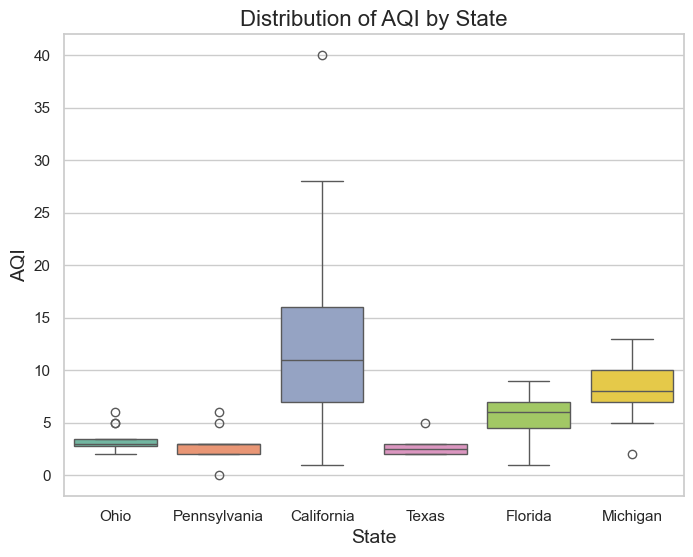

In [27]:
# Code Here
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.boxplot(x='state_name', y='aqi', data=subset_aqi, palette="Set2")
plt.title('Distribution of AQI by State', fontsize=16)
plt.xlabel('State', fontsize=14)
plt.ylabel('AQI', fontsize=14)
plt.show()

**Question:** Based on the data and your visualizations, which state(s) do you suspect will be most affected by this policy?

A: California and potentially Michigan, because California aqi has median over 10, meaning more than half are greater than 10, and Michigan has 25% of the data with aqi more than 10, which is the threshold of policy.

### Construct a confidence interval for the RRE state with the highest mean AQI

Recall the 4-step process in constructing a confidence interval:

1.   Identify a sample statistic.
2.   Choose a confidence level.
3.   Find the margin of error. 
4.   Calculate the interval.

### Construct your sample statistic

To contruct your sample statistic, find the mean AQI for your state.

In [34]:
# Find the mean aqi for your state.
aqi_ca = air_quality[air_quality['state_name']=='California']
aqi_ca_mean = aqi_ca['aqi'].mean()
aqi_ca_mean

np.float64(12.121212121212121)

### Choose your confidence level

Choose your confidence level for your analysis. The most typical confidence level chosen is 95%; however, you can choose 90% or 99% if you want decrease or increase (respectively) your level of confidence about your result.

In [32]:
# Input your confidence level here:
cl = 0.95

### Find your margin of error (ME)

Recall **margin of error = z * standard error**, where z is the appropriate z-value for the given confidence level. To calculate your margin of error:

- Find your z-value. 
- Find the approximate z for common confidence levels.
- Calculate your **standard error** estimate. 

| Confidence Level | Z Score |
| --- | --- |
| 90% | 1.65 |
| 95% | 1.96 |
| 99% | 2.58 |


In [36]:
# Calculate your margin of error.

# Begin by identifying the z associated with your chosen confidence level.

z_value = 1.96

# Next, calculate your standard error.
aqi_ca_sd = aqi_ca['aqi'].std()
aqi_ca_sd

# Lastly, use the preceding result to calculate your margin of error.
aqi_ca_se = aqi_ca_sd / np.sqrt(aqi_ca.shape[0])
aqi_ca_se


np.float64(0.8987209641127412)

### Calculate your interval

Calculate both a lower and upper limit surrounding your sample mean to create your interval.

In [40]:
# Calculate your confidence interval (upper and lower limits).
lower_bound = aqi_ca_mean - z_value * aqi_ca_se
upper_bound = aqi_ca_mean + z_value * aqi_ca_se
lower_bound, upper_bound

(np.float64(10.359719031551148), np.float64(13.882705210873095))

### Alternative: Construct the interval using `scipy.stats.norm.interval()`

`scipy` presents a simpler solution to developing a confidence interval. To use this, first import the `stats` module from `scipy`.

In [ ]:
# Import stats from scipy.
from scipy import stats

## Step 4: Results and evaluation

### Recalculate your confidence interval

Provide your chosen `confidence_level`, `sample_mean`, and `standard_error` to `stats.norm.interval()` and recalculate your confidence interval.

In [41]:
# Code Here
stats.norm.interval(cl, loc=aqi_ca_mean, scale=aqi_ca_se)

(np.float64(10.359751399400034), np.float64(13.882672843024208))

# Considerations

**What are some key takeaways that you learned from this project?**

A: By using visualization tool, we can get a brief sense of how the data look like. The confidence interval can be computed by using point estimation, z-score (confidence level) and standard deviation (standard error).

**What findings would you share with others?**

A: The aqi in California generally is higher than other RRE states with wide range. There are 95% chance that the confidence interval (10.4, 13.9) will cover the true mean aqi of the RRE states.

**What would you convey to external readers?**

A: Government should make some efforts in improving air quality in California and some counties in Michigan.

**References**

[seaborn.boxplot — seaborn 0.12.1 documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html). (n.d.). 